# Jaral Arroyo-Jefferson

My goal is to analyze four datasets that contain information about land surface temperatures before, during, and after the devastating 2018 Camp Fire in Paradise, California.

## Setup

To begin analyzing the datasets, I must first connect them to the Google Colab workspace.


In [ ]:
# This code mounts the google drive, therefore allowing me to access the datasets within my files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the os.path package for path name construction
from os import path as path

In [ ]:
# Here I am locating each individual dataset within my google drive, so my program knows where to look, this is called a file path
Paradise_CA_1 = '/content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20181007_ST_B10_pts.txt'
Paradise_CA_2 = '/content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20181108_ST_B10_pts.txt'
Paradise_CA_3 = '/content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20190127_ST_B10_pts.txt'
Paradise_CA_4 = '/content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20190924_ST_B10_pts.txt'

# For my file path names I used the Paradise_CA convention because each dataset covers that region at different dates

print("My path to the sip_data folder is {}".format(Paradise_CA_1))
print("My path to the sip_data folder is {}".format(Paradise_CA_2))
print("My path to the sip_data folder is {}".format(Paradise_CA_3))
print("My path to the sip_data folder is {}".format(Paradise_CA_4))

My path to the sip_data folder is /content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20181007_ST_B10_pts.txt
My path to the sip_data folder is /content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20181108_ST_B10_pts.txt
My path to the sip_data folder is /content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20190127_ST_B10_pts.txt
My path to the sip_data folder is /content/drive/MyDrive/mySEES/Landsat_data_files/LC08_ParadiseCA_20190924_ST_B10_pts.txt


In [ ]:
# Knowing that I will have to reference the dates corresponding to each dataset, I established this variable early during the setup period
file1_date = "11-08-2018"
file2_date = "01-27-2019"
file3_date = "09-24-2019"
file4_date = "10-07-2018"

My addition of the following code arose after arriving at the graphs portion of the assignment because I would get the following error when using the data#  variables established later on in the read_landsat_data function.

Error: too many indices for array: array is 1-dimensional, but 2 were indexed

With me being unsure why this error was occurring or how to solve it I thought that the best course of action was to refine the datasets under new variables in a simpler method that did not involve a function (which I believe is the root of the error)

Additionally, the reason why I use data10 rather than data1 is because that variable is already used in the read_landsat_data function.


In [ ]:
data10 = np.loadtxt(Paradise_CA_1, comments='#', delimiter=' ')

In [ ]:
data20 = np.loadtxt(Paradise_CA_2, comments='#', delimiter=' ')

In [ ]:
data30 = np.loadtxt(Paradise_CA_3, comments='#', delimiter=' ')

In [ ]:
data40 = np.loadtxt(Paradise_CA_4, comments='#', delimiter=' ')

In [ ]:
# Importing the numpy library with will be used later for math functions
import numpy as np

## Read in the satellite data (required)

In [ ]:
# Function to read data from the Landsat data text file
def read_landsat_data(file_path):
    with open(file_path, 'r') as file:
        # Read all lines from the file into a list of strings
        lines = file.readlines()

    # Skip the first 4 comment lines, because they are comments, and read the header
    header = lines[3].strip().split()
    # The .strip() method removes any leading or trailing whitespace, including newlines
    # The .split() method splits the line into a list of column names based on whitespace

    # Use numpy to read the data from the file, starting from the 5th line
    data = np.loadtxt(file_path, skiprows=4)

    # Return the header (column names) and the data (as a NumPy array)
    return header, data

In [ ]:
# Load each dataset by applying the read_landsat_data function
header1, data1 = read_landsat_data(Paradise_CA_1)
header2, data2 = read_landsat_data(Paradise_CA_2)
header3, data3 = read_landsat_data(Paradise_CA_3)
header4, data4 = read_landsat_data(Paradise_CA_4)

# Print the header and first few rows of data to confirm my function works properly
print("Header:", header1)
print("Sample Data from File 1:\n", data1[:5])

Header: ['#', 'point_id', 'K_int16', 'x_centroid', 'y_centroid']
Sample Data from File 1:
 [[ 1.00000e+00  4.38510e+04 -2.15298e+06  2.15724e+06]
 [ 2.00000e+00  4.38190e+04 -2.15295e+06  2.15724e+06]
 [ 3.00000e+00  4.37910e+04 -2.15292e+06  2.15724e+06]
 [ 4.00000e+00  4.37250e+04 -2.15289e+06  2.15724e+06]
 [ 5.00000e+00  4.36130e+04 -2.15286e+06  2.15724e+06]]


## Convert surface temperature data from 16-bit unsigned integer into degrees Kelvin. From Kelvin you can convert to degrees Celsius and/or Fahrenheit* (required)

In [ ]:
# function for reading only 16 bit temp column, which is the 2nd columns or 1 because the indexing starts from 0
def read_landsat_data_temp(file_path):
  with open(file_path, 'r') as file:
    lines = file.readlines()

    header = lines[3].strip().split()

    data = np.loadtxt(file_path, skiprows=4, usecols=(1,))

    return header, data

In [ ]:
# Number from USGS Landsat Data Access https://www.usgs.gov/landsat-missions/landsat-collection-2-level-2-science-products
Scale_factor = 0.00341802
Offset = 149.0

In [ ]:
# Function to convert integer data to Kelvin, inorder to learn how to preform this conversion I looked it up online
def convert_to_kelvin(data):
  # what this function does is it takes the 16 bit temperature values, multiplies it by the scale factorm, then adds the offset value (remember PEMDAS)
  K_values = data * Scale_factor + Offset

  # returns the Kelvin value as a NumPy array
  return K_values

In [ ]:
# Function to convert Kelvin to Celsius
def kelvin_to_celsius(K):
  return K - 273.15

In [ ]:
# Function to convert Kelvin to Fahrenheit
def kelvin_to_fahrenheit(K):
  return (K - 273.15) * 9/5 +32

Here I am printing the values of data1 and data2 to ensure that each has different values meaning each is properly representing different dates. Looking at the values and seeing that they are in fact different shows everything so far is good.

In [ ]:
print(data1)

[[ 1.00000e+00  4.38510e+04 -2.15298e+06  2.15724e+06]
 [ 2.00000e+00  4.38190e+04 -2.15295e+06  2.15724e+06]
 [ 3.00000e+00  4.37910e+04 -2.15292e+06  2.15724e+06]
 ...
 [ 2.61278e+05  4.10970e+04 -2.13099e+06  2.14662e+06]
 [ 2.61279e+05  4.11260e+04 -2.13096e+06  2.14662e+06]
 [ 2.61280e+05  4.11390e+04 -2.13093e+06  2.14662e+06]]


In [ ]:
print(data2)

[[ 1.00000e+00  4.23440e+04 -2.15298e+06  2.15724e+06]
 [ 2.00000e+00  4.23270e+04 -2.15295e+06  2.15724e+06]
 [ 3.00000e+00  4.23000e+04 -2.15292e+06  2.15724e+06]
 ...
 [ 2.61278e+05  3.99810e+04 -2.13099e+06  2.14662e+06]
 [ 2.61279e+05  3.99870e+04 -2.13096e+06  2.14662e+06]
 [ 2.61280e+05  3.99980e+04 -2.13093e+06  2.14662e+06]]


I used the same logic for the K_values to ensure that they also had different temperatures.

In [ ]:
print(K_values1)

[298.88359502 298.77421838 298.67851382 ... 289.47036794 289.56949052
 289.61392478]


In [ ]:
print(K_values2)

[293.73263888 293.67453254 293.582246   ... 285.65585762 285.67636574
 285.71396396]


In [ ]:
# Getting the Celsius and Fahrenheit values from the Kelvin values, by applying the previous defined functions
C_values1 = kelvin_to_celsius(K_values1)
F_values1 = kelvin_to_fahrenheit(K_values1)

In [ ]:
# Print convereted sample values to check every thing went well
print("Sample Kelvin Values from File 1:\n", K_values1[:5])
print("Sample Celsius Values from File 1:\n", C_values1[:5])
print("Sample Fahrenheit Values from File 1:\n", F_values1[:5])

Sample Kelvin Values from File 1:
 [298.88359502 298.77421838 298.67851382 298.4529245  298.07010626]
Sample Celsius Values from File 1:
 [25.73359502 25.62421838 25.52851382 25.3029245  24.92010626]
Sample Fahrenheit Values from File 1:
 [78.32047104 78.12359308 77.95132488 77.5452641  76.85619127]


## Calculate minimum, maximum, median and mean land surface temperatures for each date (required)

The NumPy library is a great resource because rather than doing long equations to calculate min, max, median, and mean, there is an already built-in function to complete those operations.

In [ ]:
# Function to calculate required statistics using numpy
def calculate_statistics(K_values):
  min_temp = np.min(K_values)
  max_temp = np.max(K_values)
  median_temp = np.median(K_values)
  mean_temp = np.mean(K_values)
  return min_temp, max_temp, median_temp, mean_temp

In [ ]:
# Apply the 16 bit temperature isolation function to all four datasets
header1, data1 = read_landsat_data_temp(Paradise_CA_1)
header2, data2 = read_landsat_data_temp(Paradise_CA_2)
header3, data3 = read_landsat_data_temp(Paradise_CA_3)
header4, data4 = read_landsat_data_temp(Paradise_CA_4)

In [ ]:
# Next once the temperature data is isolated, convert temperature 16 bit data for each dataset into Kelvin usign the convert_to_kelvin function
K_values1 = convert_to_kelvin(data1)
K_values2 = convert_to_kelvin(data2)
K_values3 = convert_to_kelvin(data3)
K_values4 = convert_to_kelvin(data4)

In [ ]:
# calculating the statistics (min, max, etc) for each dataset using the calculate_statistics function
stats1 = calculate_statistics(K_values1)
stats2 = calculate_statistics(K_values2)
stats3 = calculate_statistics(K_values3)
stats4 = calculate_statistics(K_values4)

In [ ]:
# Printing the statistics for each dataset in Kelvin

# stats1[0] - Minimum temperature value for File 1, stats1[1] - Maximum temperature value for File 1
# stats1[2] - Median temperature value for File 1, stats1[3] - Mean temperature value for File 1,
# Same convention for the other Files

# The f-string formats each value to two decimal places using :.2f
# This is where the file#_date variable comes in handy rather than having to type out the date of each I simply add the variable to the print command

print(f"Statistics for File 1 " + file1_date + f" Min: {stats1[0]:.2f} K, Max: {stats1[1]:.2f} K, Median: {stats1[2]:.2f} K, Mean: {stats1[3]:.2f} K")
print(f"Statistics for File 2 " + file2_date + f" Min: {stats2[0]:.2f} K, Max: {stats2[1]:.2f} K, Median: {stats2[2]:.2f} K, Mean: {stats2[3]:.2f} K")
print(f"Statistics for File 3 " + file3_date + f" Min: {stats3[0]:.2f} K, Max: {stats3[1]:.2f} K, Median: {stats3[2]:.2f} K, Mean: {stats3[3]:.2f} K")
print(f"Statistics for File 4 " + file4_date + f" Min: {stats4[0]:.2f} K, Max: {stats4[1]:.2f} K, Median: {stats4[2]:.2f} K, Mean: {stats4[3]:.2f} K")

Statistics for File 1 11-08-2018 Min: 283.88 K, Max: 312.08 K, Median: 295.02 K, Mean: 294.84 K
Statistics for File 2 01-27-2019 Min: 277.19 K, Max: 373.00 K, Median: 290.53 K, Mean: 298.58 K
Statistics for File 3 09-24-2019 Min: 275.98 K, Max: 304.13 K, Median: 286.36 K, Mean: 286.18 K
Statistics for File 4 10-07-2018 Min: 294.16 K, Max: 323.23 K, Median: 308.22 K, Mean: 307.66 K


In [ ]:
# Printing the statistics for each dataset in Fahrenheit

# Function to convert statistics from Kelvin to Fahrenheit
def convert_stats_to_fahrenheit(stats):
    min_K, max_K, median_K, mean_K = stats

    # Convert each statistic from Kelvin to Fahrenheit
    min_F = kelvin_to_fahrenheit(min_K)
    max_F = kelvin_to_fahrenheit(max_K)
    median_F = kelvin_to_fahrenheit(median_K)
    mean_F = kelvin_to_fahrenheit(mean_K)

    return min_F, max_F, median_F, mean_F


In [ ]:
# Convert statistics from Kelvin to Fahrenheit using the function convert_stats_to_fahrenheit
stats1_F = convert_stats_to_fahrenheit(stats1)
stats2_F = convert_stats_to_fahrenheit(stats2)
stats3_F = convert_stats_to_fahrenheit(stats3)
stats4_F = convert_stats_to_fahrenheit(stats4)

In [ ]:
# This prints all the convereted Fahrenheit Stats
print(f"Statistics for File 1 " + file1_date + f" Min: {stats1_F[0]:.2f} F, Max: {stats1_F[1]:.2f} F, Median: {stats1_F[2]:.2f} F, Mean: {stats1_F[3]:.2f} F")
print(f"Statistics for File 2 " + file2_date + f" Min: {stats2_F[0]:.2f} F, Max: {stats2_F[1]:.2f} F, Median: {stats2_F[2]:.2f} F, Mean: {stats2_F[3]:.2f} F")
print(f"Statistics for File 3 " + file3_date + f" Min: {stats3_F[0]:.2f} F, Max: {stats3_F[1]:.2f} F, Median: {stats3_F[2]:.2f} F, Mean: {stats3_F[3]:.2f} F")
print(f"Statistics for File 4 " + file4_date + f" Min: {stats4_F[0]:.2f} F, Max: {stats4_F[1]:.2f} F, Median: {stats4_F[2]:.2f} F, Mean: {stats4_F[3]:.2f} F")

Statistics for File 1 11-08-2018 Min: 51.31 F, Max: 102.08 F, Median: 71.36 F, Mean: 71.04 F
Statistics for File 2 01-27-2019 Min: 39.26 F, Max: 211.73 F, Median: 63.28 F, Mean: 77.78 F
Statistics for File 3 09-24-2019 Min: 37.09 F, Max: 87.76 F, Median: 55.78 F, Mean: 55.46 F
Statistics for File 4 10-07-2018 Min: 69.82 F, Max: 122.14 F, Median: 95.12 F, Mean: 94.13 F


## Create a colored x-y plot of temperature distribution - a map of the surface temperatures by date (optional but encouraged)



In [ ]:
# This defines the x and y coordinates from the all rows in the 3rd and 4th column of the first dataset
x_coordinates = data10[:, 2]  # Third column
y_coordinates = data10[:, 3]  # Fourth column

In [ ]:
import matplotlib.pyplot as plt

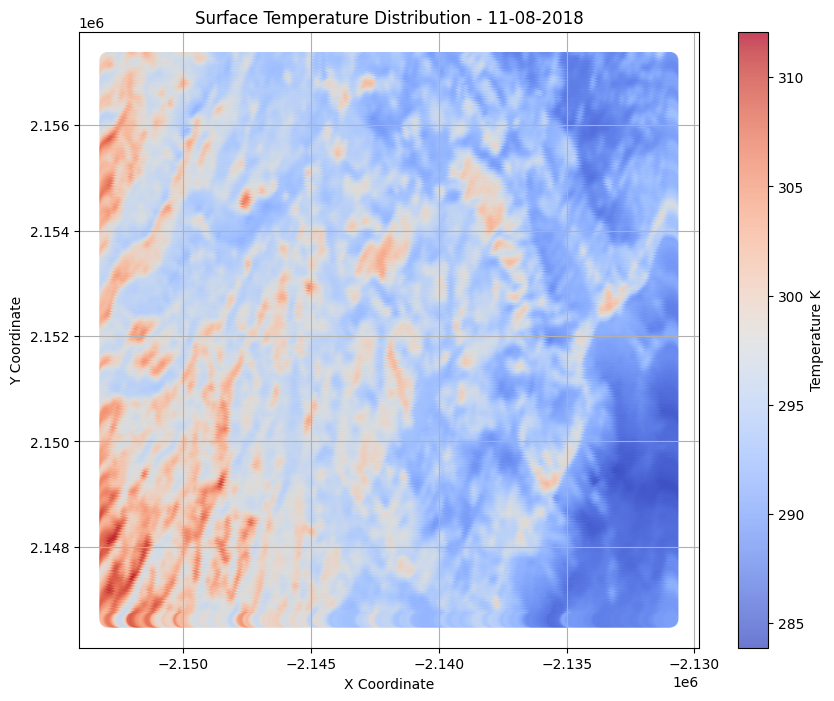

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x_coordinates, y_coordinates, c=K_values1, cmap='coolwarm', s=100, alpha=0.75)
plt.colorbar(label='Temperature K')
plt.title('Surface Temperature Distribution - ' + file1_date)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

In [ ]:
# This defines the x and y coordinates from the all rows in the 3rd and 4th column of the second dataset
x_coordinates_dos = data20[:, 2]  # Third column
y_coordinates_dos = data20[:, 3]  # Fourth column

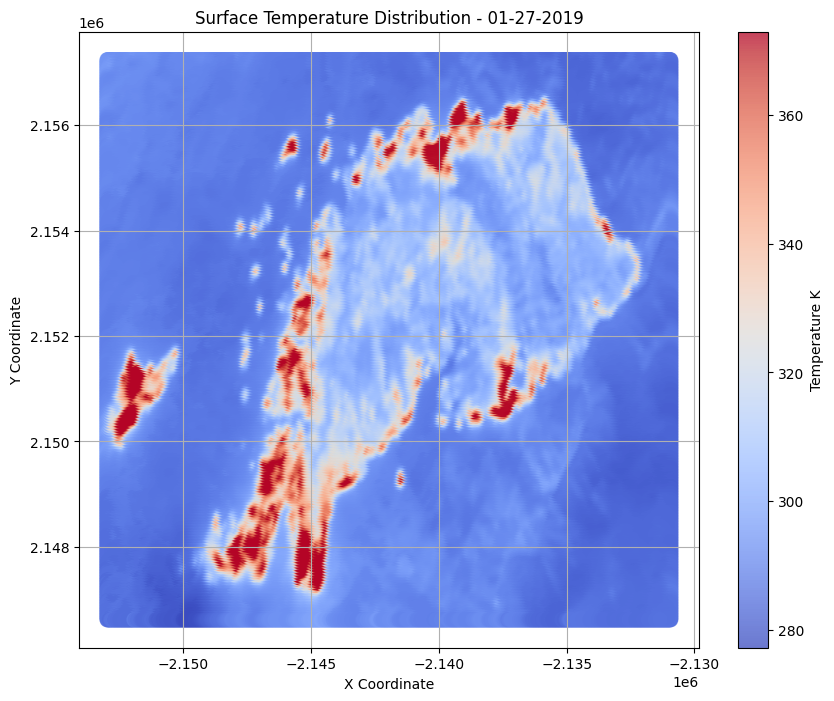

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x_coordinates_dos, y_coordinates_dos, c=K_values2, cmap='coolwarm', s=100, alpha=0.75)
plt.colorbar(label='Temperature K')
plt.title('Surface Temperature Distribution - ' + file2_date)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

In [ ]:
# This defines the x and y coordinates from the all rows in the 3rd and 4th column of the third dataset
x_coordinates_tres = data30[:, 2]  # Third column
y_coordinates_tres = data30[:, 3]  # Fourth column

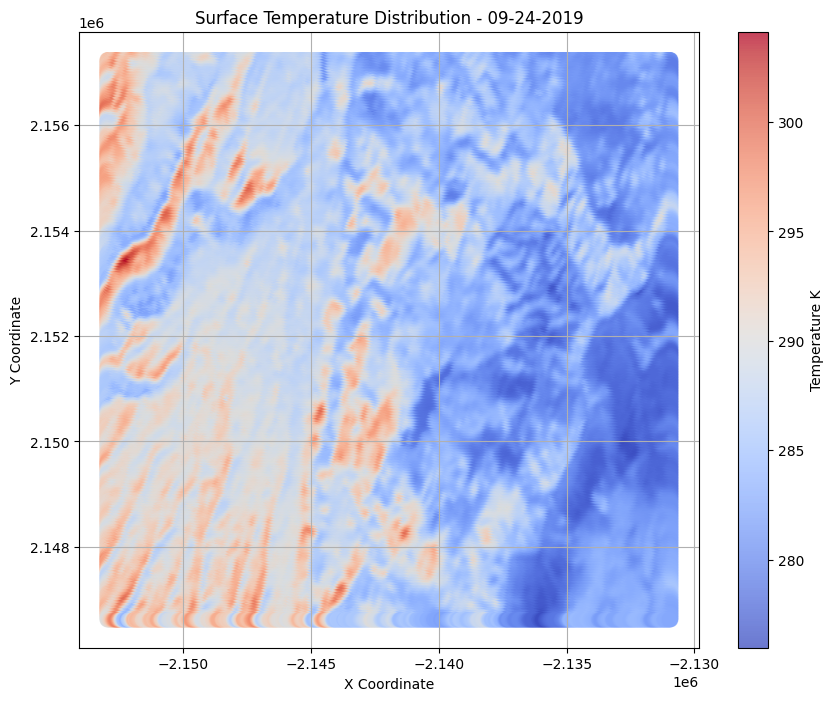

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x_coordinates_tres, y_coordinates_tres, c=K_values3, cmap='coolwarm', s=100, alpha=0.75)
plt.colorbar(label='Temperature K')
plt.title('Surface Temperature Distribution - ' + file3_date)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

In [ ]:
# This defines the x and y coordinates from the all rows in the 3rd and 4th column of the fourth dataset
x_coordinates_cuatro = data40[:, 2]  # Third column
y_coordinates_cuatro = data40[:, 3]  # Fourth column

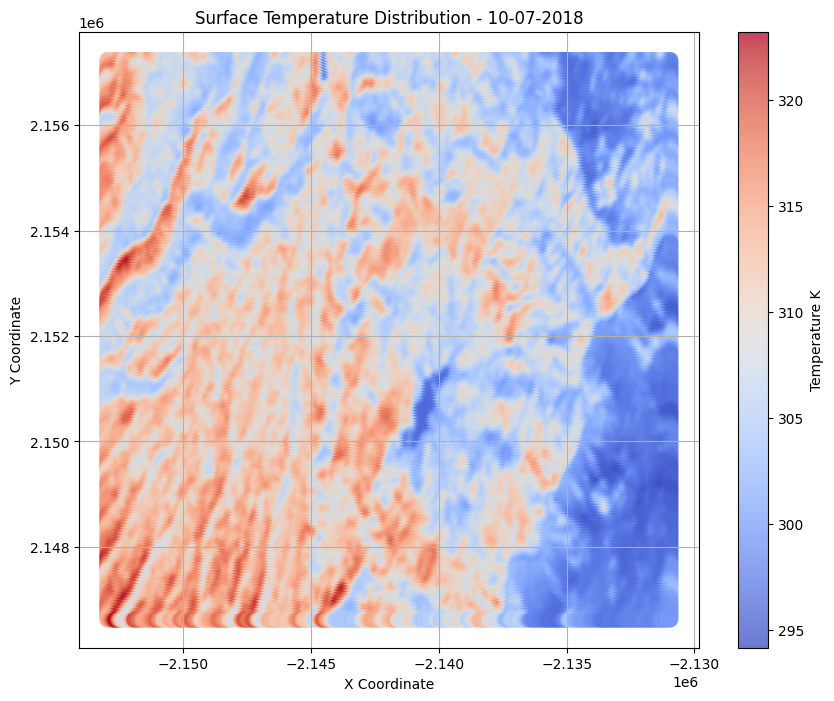

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x_coordinates_cuatro, y_coordinates_cuatro, c=K_values4, cmap='coolwarm', s=100, alpha=0.75)
plt.colorbar(label='Temperature K')
plt.title('Surface Temperature Distribution - ' + file4_date)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

## Create at a histogram showing temperature distribution by date (optional but encouraged)


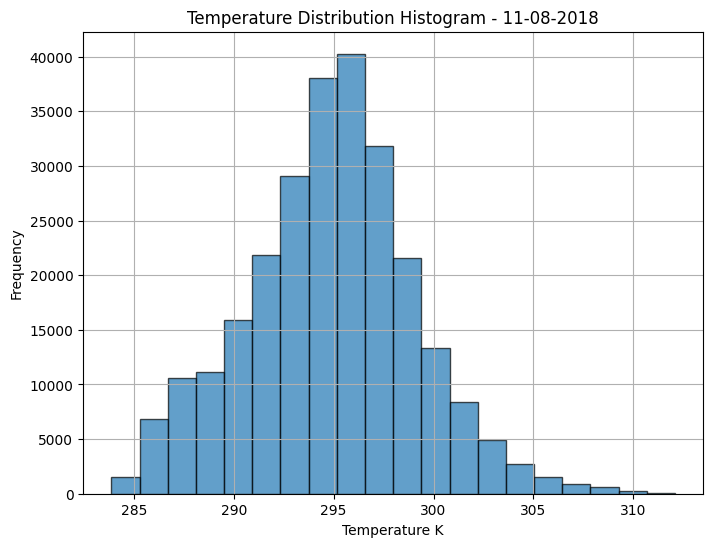

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(K_values1, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Temperature K')
plt.ylabel('Frequency')
plt.title('Temperature Distribution Histogram - ' + file1_date)
plt.grid(True)
plt.show()

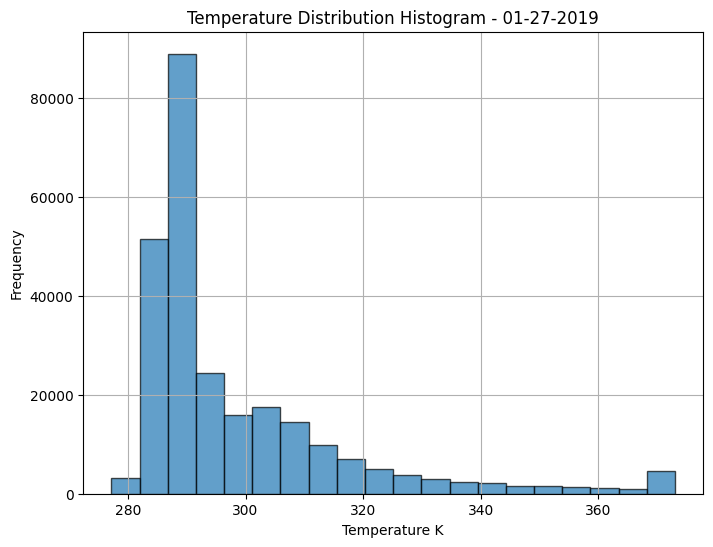

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(K_values2, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Temperature K')
plt.ylabel('Frequency')
plt.title('Temperature Distribution Histogram - ' + file2_date)
plt.grid(True)
plt.show()

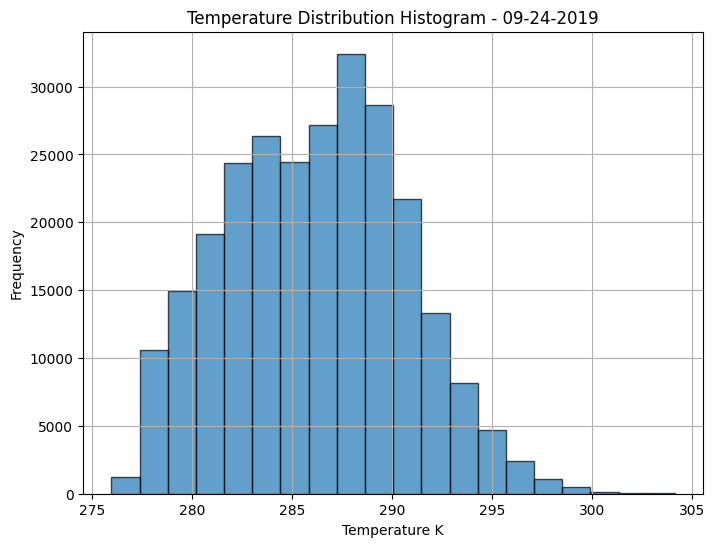

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(K_values3, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Temperature K')
plt.ylabel('Frequency')
plt.title('Temperature Distribution Histogram - ' + file3_date)
plt.grid(True)
plt.show()

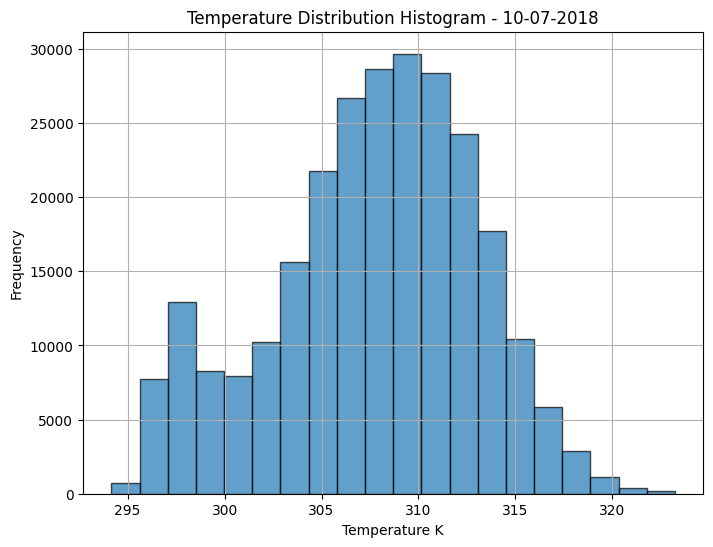

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(K_values4, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Temperature K')
plt.ylabel('Frequency')
plt.title('Temperature Distribution Histogram - ' + file4_date)
plt.grid(True)
plt.show()